# Urgency Tagging with LSTM Model

Notebook ini mengimplementasikan model Recurrent Neural Network (RNN) berbasis **Long Short-Term Memory (LSTM)** untuk melakukan klasifikasi tingkat urgensi komplain konsumen (High, Medium, Low).

## Catatan Arsitektur: LSTM vs GRU vs BiLSTM
| Model | Gates | Keunggulan |
|-------|-------|------------|
| **LSTM** | Input, Forget, Output (3 gate) | Menangkap dependensi jangka panjang, stabil untuk teks panjang |
| **GRU** | Reset, Update (2 gate) | Lebih ringan dari LSTM, training lebih cepat |
| **BiLSTM** | Sama dengan LSTM, dua arah | Memahami konteks dari dua arah (kiri→kanan & kanan→kiri) |

LSTM memiliki **cell state** terpisah sebagai "memori jangka panjang" yang tidak dimiliki GRU, sehingga secara teori lebih baik menangkap dependensi konteks yang jauh.

Pipeline yang diimplementasikan meliputi:
1. Memuat dataset ter-lemmatisasi (`cleaned_complaints.csv`)
2. Pembagian data stratified (Train, Validation, Test)
3. **[EDA]** Analisis parameter tokenisasi (vocab size & panjang sekuens)
4. Label encoding kelas target
5. Tokenisasi teks & padding sekuens teks
6. Penanganan kelas imbalanced menggunakan class weight
7. Definisi arsitektur model LSTM (Embedding, Bidirectional LSTM, Dense, Softmax)
8. Pelatihan model dengan Early Stopping & Checkpointing
9. Visualisasi performa model (Loss & Accuracy curves)
10. Evaluasi model (Classification Report & Confusion Matrix)
11. Simpan model ke direktori `models/`

In [18]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle

# Deteksi apakah berjalan di Google Colab atau lokal
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Jalur absolut menuju direktori root proyek di Drive
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    # Berjalan secara lokal (VS Code / Jupyter Notebook)
    notebook_dir = os.getcwd()
    if os.path.basename(notebook_dir) == 'notebooks':
        PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..'))
    else:
        PROJECT_ROOT = notebook_dir
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

# Tambahkan root proyek ke sys.path jika belum terdaftar
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import pipeline standard dari src.features (setelah sys.path diatur)
from src.features import split_data, extract_lstm_sequences

import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Styling untuk visualisasi
sns.set_theme(style='whitegrid')

# ── Set Global Random Seeds (Reprodusibilitas) ──────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
# ────────────────────────────────────────────────────────────────
print("Semua library berhasil diimport.")
print(f"TensorFlow version: {tf.__version__}")

# ── Manual Tuning Bobot Kelas Low ───────────────────────────────
# compute_class_weight('balanced') memberi bobot sangat tinggi pada
# kelas minoritas (Low). Terlalu agresif → model over-predict Low.
# Solusi: turunkan bobot Low sebesar 25% sebagai kompromi terkontrol.
low_idx = class_mapping.get("Low")
if low_idx is not None:
    _orig_low = class_weights_dict[low_idx]
    _reduction = 0.25  # 25% (rentang saran: 20-30%)
    class_weights_dict[low_idx] = _orig_low * (1 - _reduction)
    print(f"\nManual tuning kelas Low (idx={low_idx}):")
    print(f"  Bobot asli (balanced)  : {_orig_low:.4f}")
    print(f"  Setelah dikurangi 25%  : {class_weights_dict[low_idx]:.4f}")

print("\nBobot kelas final (setelah manual tuning):")
for class_name, class_idx in class_mapping.items():
    print(f"  {class_name:8s} (idx={class_idx}): weight = {class_weights_dict[class_idx]:.4f}")
# ────────────────────────────────────────────────────────────────


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berjalan di Google Colab. Direktori aktif saat ini: /content/drive/MyDrive/lentera-ml-research
Semua library berhasil diimport.
TensorFlow version: 2.20.0

Manual tuning kelas Low (idx=1):
  Bobot asli (balanced)  : 2.6214
  Setelah dikurangi 25%  : 1.9660

Bobot kelas final (setelah manual tuning):
  High     (idx=0): weight = 0.8654
  Low      (idx=1): weight = 1.9660
  Medium   (idx=2): weight = 0.6835


## 1. Load dan Validasi Dataset Bersih
Kita akan memuat dataset hasil pembersihan dan normalisasi teks yang telah disimpan di `data/processed/cleaned_complaints.csv`.

In [19]:
# Membaca dataset yang telah melalui proses pembersihan teks
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

# Validasi: hapus baris dengan nilai kosong pada kolom kunci
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

# Cek distribusi kelas
print("Distribusi kelas Urgency:")
print(df['Urgency'].value_counts())

Dataset berhasil dimuat. Shape awal: (53927, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (53927, 3)

Distribusi kelas Urgency:
Urgency
Medium    26299
High      20771
Low        6857
Name: count, dtype: int64


## 2. Pembagian Data (Data Splitting)
Kita membagi dataset secara stratified menjadi Train (70%), Validation (15%), dan Test (15%) dengan menggunakan fungsi `split_data` yang sudah tersedia di `src.features`.

In [20]:
# Memanggil fungsi split_data dari src.features
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

Train size: 37748, Val size: 8089, Test size: 8090


## 3. EDA Parameter Tokenisasi

Sebelum tokenisasi, kita **menganalisis data latih** untuk menentukan nilai `max_words` dan `max_len` yang tepat secara empiris — bukan menggunakan nilai hardcoded.

### Mengapa ini penting?
- **`max_words` terlalu besar** → embedding matrix boros memori tanpa manfaat nyata
- **`max_words` terlalu kecil** → terlalu banyak kata penting dianggap OOV (out-of-vocabulary)
- **`max_len` terlalu besar** → padding berlebihan, komputasi sia-sia
- **`max_len` terlalu kecil** → informasi terpotong, model kehilangan konteks penting

> ⚠️ **Analisis dilakukan hanya pada `df_train`** untuk menghindari data leakage dari validation/test set.

In [21]:
# === ANALISIS 1: Distribusi Panjang Sekuens (Token Count) ===
# Menghitung jumlah token per teks menggunakan simple whitespace split
# (proxy cepat sebelum tokenizer sesungguhnya — hasil sangat mendekati)
train_token_lengths = df_train['Cleaned_Narrative'].astype(str).apply(lambda x: len(x.split()))

# Statistik deskriptif panjang token
stats = train_token_lengths.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])

print("=" * 55)
print("  Statistik Panjang Token per Teks (Data Latih)")
print("=" * 55)
print(f"  Jumlah sampel : {len(train_token_lengths):,}")
print(f"  Min           : {train_token_lengths.min():,} token")
print(f"  Mean          : {train_token_lengths.mean():.1f} token")
print(f"  Median (P50)  : {train_token_lengths.median():.0f} token")
print(f"  P75           : {train_token_lengths.quantile(0.75):.0f} token")
print(f"  P90           : {train_token_lengths.quantile(0.90):.0f} token")
print(f"  P95           : {train_token_lengths.quantile(0.95):.0f} token")
print(f"  P99           : {train_token_lengths.quantile(0.99):.0f} token")
print(f"  Max           : {train_token_lengths.max():,} token")
print("=" * 55)

  Statistik Panjang Token per Teks (Data Latih)
  Jumlah sampel : 37,748
  Min           : 2 token
  Mean          : 98.3 token
  Median (P50)  : 73 token
  P75           : 128 token
  P90           : 199 token
  P95           : 258 token
  P99           : 446 token
  Max           : 2,586 token


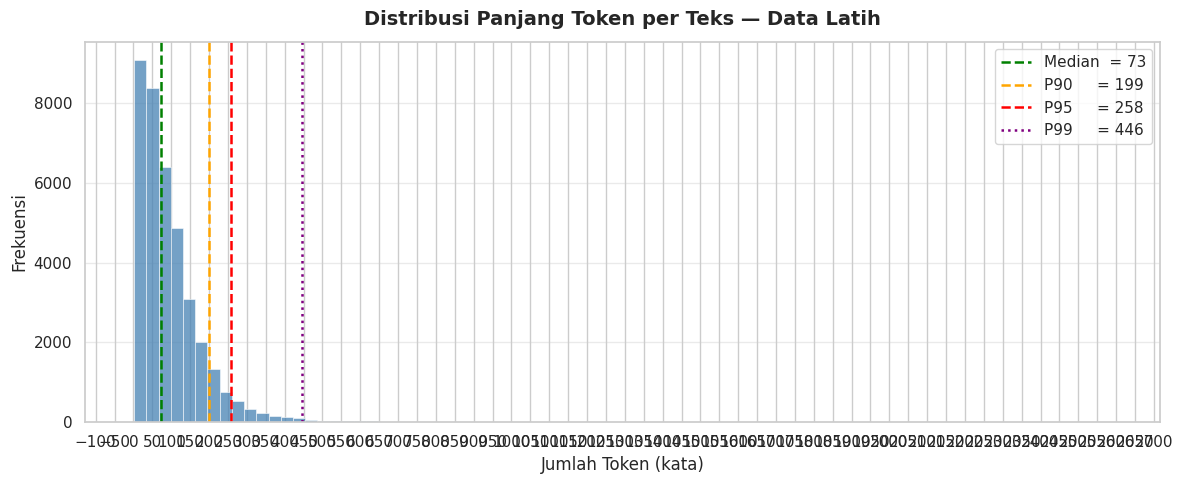


Catatan: Garis merah (P95 = 258) berarti 95% teks latih memiliki panjang ≤ 258 token.
         Hanya 1,886 teks (5.0%) yang terpotong jika max_len = 258.


In [22]:
# === VISUALISASI: Histogram distribusi panjang token ===
p90 = int(train_token_lengths.quantile(0.90))
p95 = int(train_token_lengths.quantile(0.95))
p99 = int(train_token_lengths.quantile(0.99))
median_len = int(train_token_lengths.median())

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(train_token_lengths, bins=80, color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.5)

# Garis vertikal persentil
ax.axvline(median_len, color='green',  linestyle='--', linewidth=1.8, label=f'Median  = {median_len}')
ax.axvline(p90,        color='orange', linestyle='--', linewidth=1.8, label=f'P90     = {p90}')
ax.axvline(p95,        color='red',    linestyle='--', linewidth=1.8, label=f'P95     = {p95}')
ax.axvline(p99,        color='purple', linestyle=':',  linewidth=1.8, label=f'P99     = {p99}')

ax.set_title('Distribusi Panjang Token per Teks — Data Latih', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Token (kata)', fontsize=12)
ax.set_ylabel('Frekuensi', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nCatatan: Garis merah (P95 = {p95}) berarti 95% teks latih memiliki panjang ≤ {p95} token.")
print(f"         Hanya {(train_token_lengths > p95).sum():,} teks ({(train_token_lengths > p95).mean()*100:.1f}%) yang terpotong jika max_len = {p95}.")

In [23]:
# === ANALISIS 2: Ukuran Vocabulary Aktual ===
# Fit tokenizer sementara HANYA pada data latih (tanpa batasan max_words)
# untuk melihat total kosa kata yang benar-benar ada di data ini.
print("Menghitung vocabulary aktual dari data latih...")
_probe_tokenizer = Tokenizer(oov_token="<OOV>")
_probe_tokenizer.fit_on_texts(df_train['Cleaned_Narrative'])

actual_vocab_size = len(_probe_tokenizer.word_index)  # termasuk <OOV>
print(f"\nVocabulary aktual (data latih): {actual_vocab_size:,} kata unik")
print()

# Analisis distribusi frekuensi kata untuk menentukan cutoff yang tepat
word_counts = sorted(_probe_tokenizer.word_counts.values(), reverse=True)
total_words = len(word_counts)

# Hitung coverage pada berbagai batas vocabulary
thresholds = [3000, 5000, 8000, 10000, 12000, 15000, 20000]
total_token_count = sum(word_counts)

print(f"{'max_words':>10}  {'Coverage (%)':>14}  {'Kata Diabaikan':>16}  {'Keputusan':>12}")
print("-" * 58)
for threshold in thresholds:
    if threshold >= total_words:
        coverage = 100.0
        ignored = 0
    else:
        top_n_count = sum(word_counts[:threshold])
        coverage = top_n_count / total_token_count * 100
        ignored = total_words - threshold
    
    if coverage >= 99.0:
        verdict = "✅ Sangat baik"
    elif coverage >= 97.0:
        verdict = "✅ Baik"
    elif coverage >= 95.0:
        verdict = "⚠️  Cukup"
    else:
        verdict = "❌ Kurang"
    print(f"{threshold:>10,}  {coverage:>13.2f}%  {ignored:>16,}  {verdict:>12}")

Menghitung vocabulary aktual dari data latih...

Vocabulary aktual (data latih): 24,194 kata unik

 max_words    Coverage (%)    Kata Diabaikan     Keputusan
----------------------------------------------------------
     3,000          96.73%            21,193     ⚠️  Cukup
     5,000          98.50%            19,193        ✅ Baik
     8,000          99.29%            16,193  ✅ Sangat baik
    10,000          99.50%            14,193  ✅ Sangat baik
    12,000          99.63%            12,193  ✅ Sangat baik
    15,000          99.75%             9,193  ✅ Sangat baik
    20,000          99.89%             4,193  ✅ Sangat baik


In [24]:
# === KEPUTUSAN FINAL PARAMETER TOKENISASI ===

# --- max_len: gunakan P95 panjang token, dibulatkan ke kelipatan 25 terdekat ---
p95_raw = train_token_lengths.quantile(0.95)
FINAL_MAX_LEN = int(np.ceil(p95_raw / 25) * 25)  # bulatkan ke atas ke kelipatan 25

# --- max_words: pilih nilai terkecil yang coverage-nya >= 98% ---
total_token_count = sum(word_counts)
FINAL_MAX_WORDS = None
for threshold in range(1000, actual_vocab_size + 1, 500):
    top_n = sum(word_counts[:threshold])
    if top_n / total_token_count >= 0.98:
        FINAL_MAX_WORDS = threshold
        break

# Fallback: jika vocab kecil, gunakan seluruh vocabulary
if FINAL_MAX_WORDS is None:
    FINAL_MAX_WORDS = actual_vocab_size

# Batasi agar tidak terlalu besar (efisiensi memori)
FINAL_MAX_WORDS = min(FINAL_MAX_WORDS, 20000)

print("=" * 55)
print("  KEPUTUSAN PARAMETER TOKENISASI")
print("=" * 55)
print(f"  Vocabulary aktual data latih : {actual_vocab_size:,} kata")
print(f"  P95 panjang token (raw)      : {p95_raw:.0f} token")
print()
print(f"  ✅ FINAL max_words = {FINAL_MAX_WORDS:,}")
print(f"     → Coverage ≥ 98% token dengan kosakata ini")
print()
print(f"  ✅ FINAL max_len   = {FINAL_MAX_LEN}")
print(f"     → P95 ({p95_raw:.0f}) dibulatkan ke kelipatan 25")
print(f"     → Hanya {(train_token_lengths > FINAL_MAX_LEN).mean()*100:.1f}% teks yang terpotong")
print("=" * 55)
print()
print("Variabel FINAL_MAX_WORDS dan FINAL_MAX_LEN siap digunakan di langkah selanjutnya.")

  KEPUTUSAN PARAMETER TOKENISASI
  Vocabulary aktual data latih : 24,194 kata
  P95 panjang token (raw)      : 258 token

  ✅ FINAL max_words = 4,500
     → Coverage ≥ 98% token dengan kosakata ini

  ✅ FINAL max_len   = 275
     → P95 (258) dibulatkan ke kelipatan 25
     → Hanya 4.2% teks yang terpotong

Variabel FINAL_MAX_WORDS dan FINAL_MAX_LEN siap digunakan di langkah selanjutnya.


## 4. Label Encoding Target
Model deep learning membutuhkan target numerik. Kita akan mengodekan target kategori `'High'`, `'Medium'`, dan `'Low'` menggunakan `LabelEncoder` dari scikit-learn.

In [25]:
# Label encoding target 'Urgency' menjadi integer
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(df_train['Urgency'])
y_val_encoded = label_encoder.transform(df_val['Urgency'])
y_test_encoded = label_encoder.transform(df_test['Urgency'])

# Tampilkan pemetaan kelas
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Pemetaan kelas target:", class_mapping)

Pemetaan kelas target: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 5. Tokenisasi dan Padding Sekuens

Kita mengubah teks komplain menjadi representasi sekuens integer menggunakan `extract_lstm_sequences` dari `src.features`.

Parameter yang digunakan berasal dari hasil **EDA Step 3** di atas:
- `max_words` = `FINAL_MAX_WORDS` (ditentukan dari coverage ≥ 98% vocabulary aktual)
- `max_len` = `FINAL_MAX_LEN` (P95 panjang token, dibulatkan ke kelipatan 25)

In [26]:
# Ekstraksi tokenisasi sekuens teks menggunakan parameter dari EDA
X_train_pad, X_val_pad, X_test_pad, tokenizer = extract_lstm_sequences(
    df_train['Cleaned_Narrative'],
    df_val['Cleaned_Narrative'],
    df_test['Cleaned_Narrative'],
    max_words=FINAL_MAX_WORDS,
    max_len=FINAL_MAX_LEN
)

print(f"Parameter yang digunakan:")
print(f"  max_words = {FINAL_MAX_WORDS:,}")
print(f"  max_len   = {FINAL_MAX_LEN}")
print()
print(f"Shape data sekuens:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")
print()

# Verifikasi: vocabulary yang benar-benar dipakai tokenizer
effective_vocab = len(tokenizer.word_index)
print(f"Vocabulary efektif tokenizer : {effective_vocab:,} kata")
print(f"(Dibatasi max_words = {FINAL_MAX_WORDS:,}, termasuk token <OOV>)")

Parameter yang digunakan:
  max_words = 4,500
  max_len   = 275

Shape data sekuens:
  X_train_pad : (37748, 275)
  X_val_pad   : (8089, 275)
  X_test_pad  : (8090, 275)

Vocabulary efektif tokenizer : 24,194 kata
(Dibatasi max_words = 4,500, termasuk token <OOV>)


## 6. Penanganan Kelas Imbalanced
Karena sebaran kelas target tidak merata, kita menghitung *class weight* untuk menaikkan bobot kelas minoritas selama pelatihan agar model tidak condong ke kelas mayoritas.

In [27]:
# Hitung bobot kelas berdasarkan distribusi target training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights_dict = dict(enumerate(class_weights))
print("Bobot kelas:")

# ── Manual Tuning Bobot Kelas Low ───────────────────────────────
# compute_class_weight('balanced') memberi bobot sangat tinggi pada
# kelas minoritas (Low). Terlalu agresif → model over-predict Low.
# Solusi: turunkan bobot Low sebesar 25% sebagai kompromi terkontrol.
low_idx = class_mapping.get("Low")
if low_idx is not None:
    _orig_low = class_weights_dict[low_idx]
    _reduction = 0.25  # 25% (rentang saran: 20-30%)
    class_weights_dict[low_idx] = _orig_low * (1 - _reduction)
    print(f"\nManual tuning kelas Low (idx={low_idx}):")
    print(f"  Bobot asli (balanced)  : {_orig_low:.4f}")
    print(f"  Setelah dikurangi 25%  : {class_weights_dict[low_idx]:.4f}")

print("\nBobot kelas final (setelah manual tuning):")
for class_name, class_idx in class_mapping.items():
    print(f"  {class_name:8s} (idx={class_idx}): weight = {class_weights_dict[class_idx]:.4f}")
# ────────────────────────────────────────────────────────────────


Bobot kelas:

Manual tuning kelas Low (idx=1):
  Bobot asli (balanced)  : 2.6214
  Setelah dikurangi 25%  : 1.9660

Bobot kelas final (setelah manual tuning):
  High     (idx=0): weight = 0.8654
  Low      (idx=1): weight = 1.9660
  Medium   (idx=2): weight = 0.6835


## 7. Definisi Arsitektur Model LSTM
Kita membangun arsitektur model sekuensial dengan lapisan-lapisan:
- **Input**: Menerima token sekuens berukuran `FINAL_MAX_LEN` (ditentukan dari EDA).
- **Embedding**: Mengubah indeks integer kata menjadi representasi vektor padat 128 dimensi.
- **Bidirectional LSTM**: Lapisan berulang LSTM dua arah berukuran 128 unit untuk menangkap relasi kontekstual teks baik dari arah depan maupun belakang. LSTM menggunakan 3 gate (Input, Forget, Output) + Cell State sehingga lebih baik menangkap dependensi jangka panjang dibanding GRU.
- **Dense (Hidden)**: Lapisan padat 32 unit dengan aktivasi ReLU.
- **Dropout**: Lapisan dropout 0.5 untuk mengurangi risiko overfitting.
- **Output**: Lapisan Dense 3 unit dengan aktivasi Softmax untuk menghasilkan distribusi probabilitas kategori (High, Medium, Low).

### Perbedaan LSTM vs GRU (pada proyek ini)
| Komponen | GRU (notebook sebelumnya) | LSTM (notebook ini) |
|----------|--------------------------|---------------------|
| Layer RNN | `Bidirectional(GRU(128))` | `Bidirectional(LSTM(128))` |
| Gate | 2 (Reset, Update) | 3 (Input, Forget, Output) |
| State | Hidden state saja | Hidden state + Cell state |
| Parameter | ~198K | ~230K |
| Training speed | Lebih cepat | Sedikit lebih lambat |

In [28]:
# Hyperparameter model — vocab_size dan max_len dari hasil EDA
vocab_size    = FINAL_MAX_WORDS   # dari EDA Step 3
embedding_dim = 128
max_len       = FINAL_MAX_LEN     # dari EDA Step 3
num_classes   = len(class_mapping)

print(f"Hyperparameter model:")
print(f"  vocab_size    = {vocab_size:,}")
print(f"  embedding_dim = {embedding_dim}")
print(f"  max_len       = {max_len}")
print(f"  num_classes   = {num_classes}")
print()

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Hyperparameter model:
  vocab_size    = 4,500
  embedding_dim = 128
  max_len       = 275
  num_classes   = 3



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 275, 128)       │       576,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,491 (3.23 MB)

 Trainable params: 847,491 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Pelatihan Model (Training)
Model dilatih dengan epochs=50 dan *Early Stopping* sebagai penjaga utama penghentian pelatihan. Pendekatan ini mengikuti best practice:
- **Jangan batasi epoch terlalu kecil** — biarkan model belajar hingga benar-benar konvergen
- **Early Stopping** yang bekerja nyata: berhenti otomatis saat al_loss tidak membaik selama **7 epoch berturut-turut** (patience=7), lalu kembalikan bobot terbaik
- **ModelCheckpoint**: menyimpan model terbaik (berdasarkan al_loss) secara otomatis ke direktori models/

> *Menggunakan epochs=10, patience=3 (versi lama) berisiko menghentikan training terlalu dini sebelum model sempat konvergen.*

In [29]:
# Path penyimpanan model terbaik
MODEL_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'lstm_urgency_model.keras')

# Inisialisasi callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Pelatihan model
# epochs besar + Early Stopping (patience=5) adalah kombinasi best practice:
# training berhenti sendiri saat val_loss stagnan, bukan dibatasi epoch kecil.
epochs = 50
batch_size = 64

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, model_checkpoint]
)

print(f"\nModel terbaik disimpan di: {MODEL_SAVE_PATH}")

Epoch 1/50
589/590 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5822 - loss: 0.7802
Epoch 1: val_loss improved from None to 0.51788, saving model to /content/drive/MyDrive/lentera-ml-research/models/lstm_urgency_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lentera-ml-research/models/lstm_urgency_model.keras
590/590 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.6805 - loss: 0.6677 - val_accuracy: 0.7989 - val_loss: 0.5179
Epoch 2/50
589/590 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7939 - loss: 0.4997
Epoch 2: val_loss improved from 0.51788 to 0.50933, saving model to /content/drive/MyDrive/lentera-ml-research/models/lstm_urgency_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lentera-ml-research/models/lstm_urgency_model.keras
590/590 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.7930 - loss: 0.4844 - val_accuracy: 0.7565 - val_loss: 0.5093
Epoch 3/50
589/590 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7960 - loss: 0.460

## 9. Visualisasi Riwayat Pelatihan
Menampilkan plot Loss dan Akurasi sepanjang epoch pelatihan untuk mengamati ada tidaknya gejala underfitting atau overfitting.

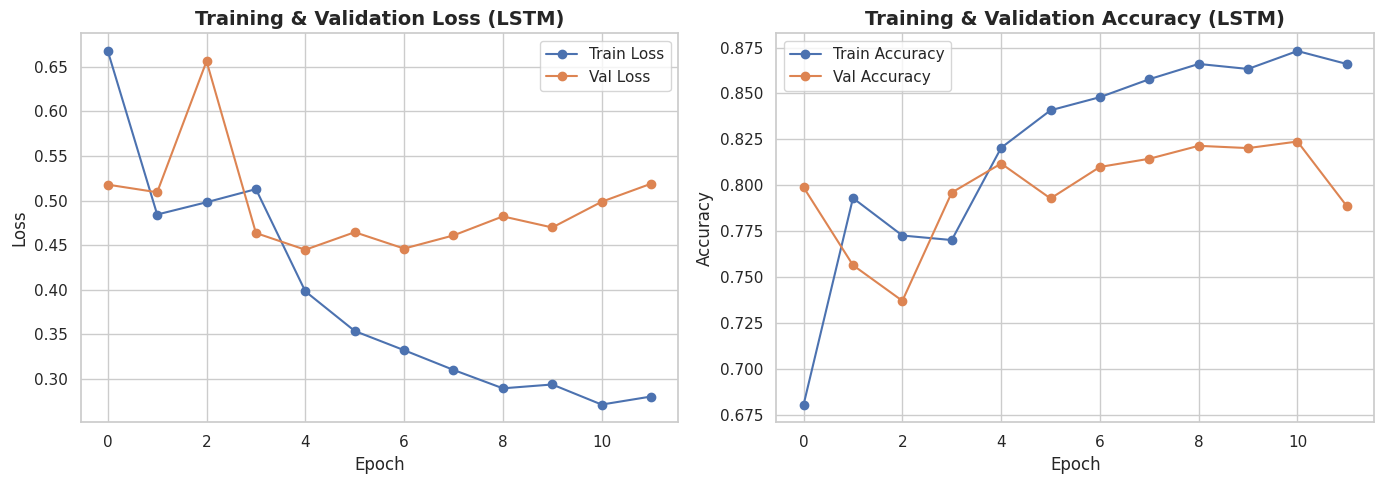

Plot riwayat pelatihan disimpan.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training & Validation Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Training & Validation Loss (LSTM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot Training & Validation Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[1].set_title('Training & Validation Accuracy (LSTM)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'models', 'lstm_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot riwayat pelatihan disimpan.")

## 10. Evaluasi Model
Kita mengevaluasi performa model menggunakan **Classification Report** (Precision, Recall, F1-Score per kelas) dan **Confusion Matrix** pada data test yang belum pernah dilihat model.

In [31]:
# Prediksi pada test set
y_pred_proba = model.predict(X_test_pad, batch_size=64)
y_pred = np.argmax(y_pred_proba, axis=1)

# Evaluasi keseluruhan
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded, batch_size=64, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print()

# Classification Report
print("=" * 60)
print("Classification Report (LSTM - Test Set)")
print("=" * 60)
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Test Loss    : 0.4486
Test Accuracy: 0.8109 (81.09%)

Classification Report (LSTM - Test Set)
              precision    recall  f1-score   support

        High       0.89      0.84      0.86      3116
         Low       0.54      0.88      0.67      1029
      Medium       0.88      0.77      0.82      3945

    accuracy                           0.81      8090
   macro avg       0.77      0.83      0.78      8090
weighted avg       0.84      0.81      0.82      8090



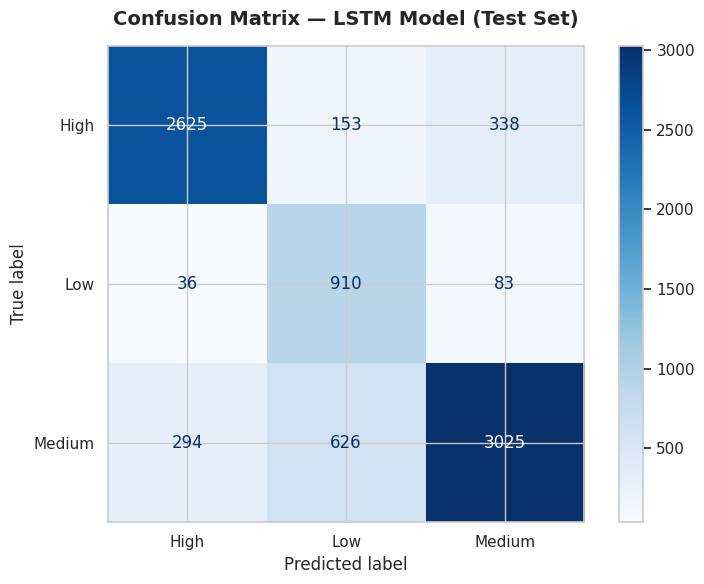

Confusion matrix disimpan.


In [32]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    ax=ax
)

ax.set_title('Confusion Matrix — LSTM Model (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'models', 'lstm_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan.")

## 11. Simpan Tokenizer & Label Encoder
Tokenizer dan label encoder perlu disimpan bersamaan dengan model agar dapat digunakan kembali saat inferensi (prediksi data baru).

In [33]:
# Simpan tokenizer
TOKENIZER_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'lstm_tokenizer.pkl')

with open(TOKENIZER_SAVE_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)

print(f"Tokenizer disimpan di    : {TOKENIZER_SAVE_PATH}")

# Simpan label encoder
LABEL_ENCODER_SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'lstm_label_encoder.pkl')

with open(LABEL_ENCODER_SAVE_PATH, 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"Label encoder disimpan di: {LABEL_ENCODER_SAVE_PATH}")

print()
print("=" * 60)
print("Summary Artifact yang Disimpan:")
print(f"  Model      : models/lstm_urgency_model.keras")
print(f"  Tokenizer  : models/lstm_tokenizer.pkl")
print(f"  LabelEnc   : models/lstm_label_encoder.pkl")
print(f"  Plot Loss  : models/lstm_training_history.png")
print(f"  Plot CM    : models/lstm_confusion_matrix.png")
print("="*60)
print()
print("Parameter Tokenisasi yang Digunakan (dari EDA):")
print(f"  max_words = {FINAL_MAX_WORDS:,}")
print(f"  max_len   = {FINAL_MAX_LEN}")

Tokenizer disimpan di    : /content/drive/MyDrive/lentera-ml-research/models/lstm_tokenizer.pkl
Label encoder disimpan di: /content/drive/MyDrive/lentera-ml-research/models/lstm_label_encoder.pkl

Summary Artifact yang Disimpan:
  Model      : models/lstm_urgency_model.keras
  Tokenizer  : models/lstm_tokenizer.pkl
  LabelEnc   : models/lstm_label_encoder.pkl
  Plot Loss  : models/lstm_training_history.png
  Plot CM    : models/lstm_confusion_matrix.png

Parameter Tokenisasi yang Digunakan (dari EDA):
  max_words = 4,500
  max_len   = 275
